# Double Descent in Linear Models

## 1. Data generation

We generate a regression dataset with noisy linear labels:
`y = X·beta + noise`, with Gaussian inputs and Gaussian noise.

The ambient dimension `D` is the maximum number of available features.
Model complexity will then be controlled by using only the first `d`
columns of `X` (with `d` from 1 up to `D`): this is what lets us cross the
interpolation threshold `d = n` and observe double descent.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# core functions from our module
from double_descent import generate_data

# global seed for reproducibility
SEED = 0
rng = np.random.default_rng(SEED)

In [5]:
# starting parameters
D = 200          # ambient dimension = maximum number of features
n_train = 40     # training set size (fixed)
n_test = 1000    # test set size (large, for an accurate error estimate)
noise_std = 0.5  # noise standard deviation

X_train, y_train, X_test, y_test, beta = generate_data(
    n_train, n_test, D, noise_std, rng
)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("beta:   ", beta.shape, "| norm =", round(float(np.linalg.norm(beta)), 3))

X_train: (40, 200)
X_test:  (1000, 200)
beta:    (200,) | norm = 1.0


### Sanity check: are the labels really linear + noise?

We plot the observed label `y` against the true signal `X·beta`.
If the data model is correct, the points should lie along the diagonal,
with scatter caused only by the noise.

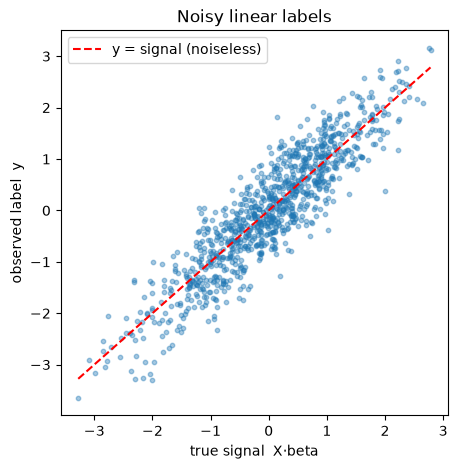

In [6]:
signal_test = X_test @ beta

plt.figure(figsize=(5, 5))
plt.scatter(signal_test, y_test, s=10, alpha=0.4)
plt.plot([signal_test.min(), signal_test.max()],
         [signal_test.min(), signal_test.max()],
         "r--", label="y = signal (noiseless)")
plt.xlabel("true signal  X·beta")
plt.ylabel("observed label  y")
plt.title("Noisy linear labels")
plt.legend()
plt.show()

## 2. Estimators (from scratch)

We implement two estimators by hand (no sklearn `.fit`):

- **Least squares** via the minimum-norm pseudoinverse, computed explicitly
  from the SVD. One formula covers both regimes (below and above the
  interpolation threshold).
- **Ridge regression** in closed form, `w = (X^T X + lam I)^(-1) X^T y`.

numpy is used only for the underlying matrix algebra.

In [7]:
from double_descent import fit_least_squares, fit_ridge, predict, mse

### 2.1 Sanity check

We fit least squares using the first `d` columns of `X` for three values of `d`:
one below the threshold, one at the threshold (`d = n_train`), one above it.

Expected behavior:
- `d` below threshold: non-zero train error, moderate test error;
- `d = n_train` (peak): the model interpolates (train ≈ 0) but test error
  and `||w||` blow up;
- `d` above threshold: still interpolates (train ≈ 0), but test error and
  `||w||` come back down. This is double descent already visible in 3 numbers.

In [8]:
# helper: fit least squares on the first d features, report train/test MSE and ||w||
def evaluate_ls(X_train, y_train, X_test, y_test, d):
    Xtr, Xte = X_train[:, :d], X_test[:, :d]
    w = fit_least_squares(Xtr, y_train)
    return mse(y_train, predict(Xtr, w)), mse(y_test, predict(Xte, w)), np.linalg.norm(w)

for d in [20, n_train, 80]:   # below threshold, at threshold, above threshold
    tr, te, wn = evaluate_ls(X_train, y_train, X_test, y_test, d)
    print(f"d = {d:3d} | train MSE = {tr:10.4e} | test MSE = {te:12.4f} | ||w|| = {wn:10.3f}")

d =  20 | train MSE = 5.0139e-01 | test MSE =       1.8934 | ||w|| =      0.930
d =  40 | train MSE = 5.2593e-29 | test MSE =     132.0439 | ||w|| =     11.464
d =  80 | train MSE = 5.7575e-30 | test MSE =       1.5929 | ||w|| =      0.807


### 2.2 Ridge: quick check

At the problematic complexity `d = n_train`, we compare least squares with
ridge (small `lam`). Ridge should give a much smaller test error and a much
smaller `||w||`: a first preview of how regularization removes the peak.

In [9]:
d = n_train
lam = 1e-2

w_ls = fit_least_squares(X_train[:, :d], y_train)
w_ridge = fit_ridge(X_train[:, :d], y_train, lam)

Xte = X_test[:, :d]
for name, w in [("least squares", w_ls), ("ridge (lam=1e-2)", w_ridge)]:
    print(f"{name:18s} | test MSE = {mse(y_test, predict(Xte, w)):12.4f} | ||w|| = {np.linalg.norm(w):10.3f}")

least squares      | test MSE =     132.0439 | ||w|| =     11.464
ridge (lam=1e-2)   | test MSE =      85.9013 | ||w|| =      9.233
